# BA820 Milestone II

**Course:** BA820 - Unsupervised and Unstructured Machine Learning  
**Author:**  Michael Allieri

**Dataset:** Hollywood Age Gaps (age_gaps.csv)  

---

## Executive Summary

This notebook demonstrates **question-driven exploratory data analysis (EDA)** for the following dataset:

1. **Hollywood Age Gaps (Primary):** on-screen couples, actor ages, and gender pairings across movies and time.


The goal is to:
- build **domain understanding** before picking algorithms
- discover **patterns** that motivate research questions
- verify whether **unsupervised methods** (clustering / dimensionality reduction) are feasible and meaningful

**Guiding idea:** Unsupervised learning should be motivated by real structure in the data — not just “running K-Means because we can.”


## Project Motivation and Problem Statement:

In the first milestone, our team wanted to examine the age differences between romantic leads in Hollywood movies to understand whether casting choices systematically favor older men paired with younger partners and how these patterns vary across time and filmmakers. In the this next milestone, my task was to examine if directors differ systematically in the age gaps and gender pairings they portray and what might these patterns suggest about individual stylistic preferences or industry positioning? This will help identify whether age-gap patterns are partly driven by creative decision makers (director "style") opposed to being only a general industry trend.

## Table of Contents

### Part I: Hollywood Age Gaps (Primary)
1. Dataset Overview & Research Motivation  
2. Temporal Patterns → *Supports “trajectory / era” clustering question*  
3. Pairing Heterogeneity → *Supports “relationship archetype” question*  
4. Casting Dynamics → *Supports “older-star effect / outliers” question*   
5. Summary: Research Questions Validated

### Part II: African Farm - Led Irrigation System (Backup)
7. Dataset Overview & Research Motivation  
8. Village & Household Heterogeneity → *Supports “targeting / archetypes” question*  
9. Multivariate Relationships → *Supports PCA + clustering at the household level*  
10. Summary: Research Questions Validated

### Part III: Synthesis
11. Key Findings Across Both Datasets  
12. Conclusion / Next Steps


In [ ]:
# Install packages
!pip install -q seaborn>=0.12.0 scikit-learn>=1.2.0

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


In [ ]:
# Helper functions

def basic_overview(df, name="Dataset"):
    print(f"===== {name} =====")
    print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"Duplicate rows: {df.duplicated().sum():,}")
    print("\nMissing values (top 10):")
    miss = df.isna().sum().sort_values(ascending=False)
    miss = miss[miss > 0].head(10)
    if len(miss) == 0:
        print("No missing values.")
    else:
        display(miss.to_frame("missing_count"))

def dataset_summary_table(df):
    summary = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_%": (df.isna().mean()*100).round(2),
        "n_unique": df.nunique(dropna=True)
    }).sort_values(["missing_%","n_unique"], ascending=[False, False])
    return summary

def safe_read_csv(path_or_name):

    candidates = [
        path_or_name,
        os.path.join("/content", path_or_name),
    ]
    for p in candidates:
        if os.path.exists(p):
            return pd.read_csv(p)
    raise FileNotFoundError(
        f"Could not find {path_or_name}. If running in Colab, upload the CSVs first."
    )


---
# PART I: HOLLYWOOD AGE GAPS (Primary)

## 1) Dataset Overview & Research Motivation

### Dataset: age_gaps.csv

**What it captures:**  
Each row is an **on-screen couple** in a movie, with actor ages, character genders and the age difference.

**Why this dataset?**
- Real, interpretable topic: media representation + casting patterns
- Natural “grouping” questions (era patterns, pairing types, movie archetypes)
- Suitable for unsupervised learning at the **movie level** (cluster movies by relationship patterns)

### Key variables
- release_year (time)
- age_difference (main outcome of interest)
- actor_1_age, actor_2_age (older vs younger actor)
- character_1_gender, character_2_gender (pairing type)
- movie_name, director, couple_number (identifiers)


In [ ]:
# Load dataset
age = safe_read_csv("age_gaps.csv")

basic_overview(age, "Hollywood Age Gaps")
display(age.head())
display(dataset_summary_table(age))

===== Hollywood Age Gaps =====
Shape: 1,155 rows × 13 columns
Duplicate rows: 0

Missing values (top 10):
No missing values.


,movie_name,release_year,director,age_difference,couple_number,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_birthdate,actor_2_birthdate,actor_1_age,actor_2_age
0,Harold and Maude,1971,Hal Ashby,52,1,Ruth Gordon,Bud Cort,woman,man,1896-10-30,1948-03-29,75,23
1,Venus,2006,Roger Michell,50,1,Peter O'Toole,Jodie Whittaker,man,woman,1932-08-02,1982-06-03,74,24
2,The Quiet American,2002,Phillip Noyce,49,1,Michael Caine,Do Thi Hai Yen,man,woman,1933-03-14,1982-10-01,69,20
3,The Big Lebowski,1998,Joel Coen,45,1,David Huddleston,Tara Reid,man,woman,1930-09-17,1975-11-08,68,23
4,Beginners,2010,Mike Mills,43,1,Christopher Plummer,Goran Visnjic,man,man,1929-12-13,1972-09-09,81,38


,column,dtype,missing,missing_%,n_unique
movie_name,movie_name,object,0,0.0,830
actor_2_name,actor_2_name,object,0,0.0,647
actor_2_birthdate,actor_2_birthdate,object,0,0.0,640
actor_1_name,actor_1_name,object,0,0.0,567
actor_1_birthdate,actor_1_birthdate,object,0,0.0,562
director,director,object,0,0.0,510
release_year,release_year,int64,0,0.0,82
actor_1_age,actor_1_age,int64,0,0.0,59
age_difference,age_difference,int64,0,0.0,46
actor_2_age,actor_2_age,int64,0,0.0,45


## Director Patterns

**Research Question:**  
What are the patterns of different directors' age gap and gender pairings? What do these patterns suggest about individual stylistic preferences or industry positioning?

In [ ]:
# Mean age gap trend by director
dir_stats = age.groupby('director')['age_difference'].agg(['count','mean','median','std']).reset_index().round(2)
dir_stats=dir_stats[dir_stats['count']>=3]
dir_stats=dir_stats.sort_values('mean',ascending=False)
dir_stats=dir_stats.dropna()
pd.set_option('display.max_rows', None)
display(dir_stats)

,director,count,mean,median,std
413,Roger Michell,3,30.00,33.0,21.66
123,Eli Roth,3,22.00,24.0,4.36
13,Alfred Hitchcock,7,21.00,22.0,5.23
317,Michel Gondry,3,20.67,15.0,11.59
202,Jerry Zucker,3,20.33,16.0,13.05
504,Woody Allen,20,20.15,18.5,11.26
217,John Glen,15,19.87,21.0,7.31
171,Howard Hawks,4,19.25,24.5,10.84
236,Jonathan Lynn,4,19.25,19.0,11.95
209,Joel Coen,5,19.00,11.0,17.56


**Explanation of Process**

In this table, we are trying to show each directors count of movies directed along with the mean, median, and std of age differences. I also made sure to only include directors that have directed 3 or more movies so that we can both get a mean and median that is not just from 1 or 2 movies. I also believe that if a director has directed 3 movies or more, it means that they have been successful. This is different from what we did before as in our proposal we did not dropna nor did we exclude any directors if they have directed enough movies. This matters for analysis because it gives us a more accurate representation on how each director chooses to pair his love interest. I also decided to order the directors age difference from largest to smallest. The range was betweeen 2.40 and 30.

**Categorical** **to** **Numerical**

In order to run a clustering, I needed to transform character gender to an integer. The first 4 lines of the code, standarizes these columns and creates a new pairing column. Then the next line of code, checks to see if the pairing column equals a specific column, then converts the result into 1 or 0, which creates a new numeric indicator column.


In [ ]:
age["pairing"] = (
    age["character_1_gender"].astype(str).str.strip().str.lower()
    + "–" +
    age["character_2_gender"].astype(str).str.strip().str.lower()
)
age['OM']=(age['pairing']=='man–woman').astype(int)
age['OF']=(age['pairing']=='man-woman').astype(int)
age['Male_Male']=(age['pairing']=='man-man').astype(int)
age['Female_Female']=(age['pairing']=='woman-woman').astype(int)


**Director Level Features to KMeans**
Here I decided to group all rows by director and display summary stats. Then I made sure to drop all directors with missing values. Once I dropped the missing values I created the feature matrix and standardized the features. Then I fit the K-means and assign clusters

In [ ]:
dir_features=(age.groupby('director').agg(Avg_Gap=('age_difference','mean'),Std_Gap=('age_difference','std'),OM=('OM','mean'),OF=('OF','mean'),Male_Male=('Male_Male','mean'), Female_Female=('Female_Female','mean')).reset_index())
dir_features = dir_features.dropna()
X=dir_features.drop(columns=['director'])
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
kmeans=KMeans(n_clusters=3,random_state=42)
dir_features['cluster']=kmeans.fit_predict(X_scaled)

In [ ]:
dir_features.drop(columns=['director']).groupby('cluster').mean()

,Avg_Gap,Std_Gap,OM,OF,Male_Male,Female_Female
cluster,,,,,,
0,6.139328,4.550409,0.477003,0.0,0.0,0.0
1,17.279462,12.090633,0.810624,0.0,0.0,0.0
2,9.380559,4.669057,0.974154,0.0,0.0,0.0


**Interpretation**
In the following table, we can see each clusters average age gap as well as the standard deviation of each gap. We can then see the proporations for each pairings of couples. What we can see is that the overwhelming proporation of cluster 1 an cluster 2 is OM. We can also see that the Male Male and Female-Female or zero. Using this, as well as the following pairplot, I was able to limit the pairings as the others were irrelevant.

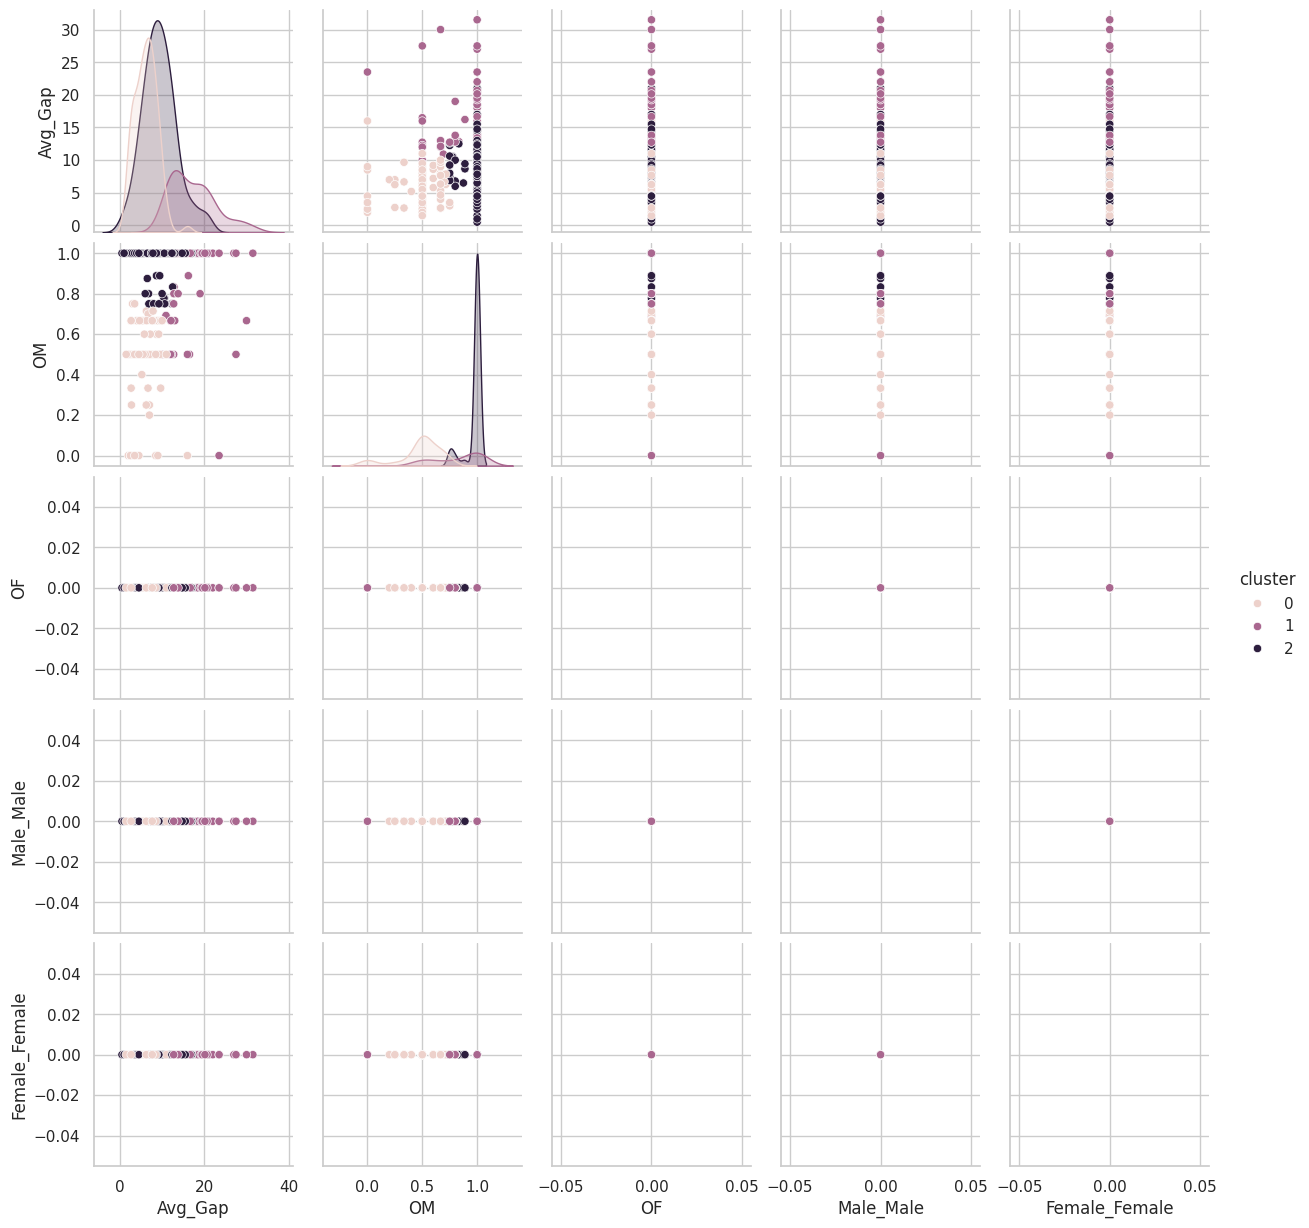

In [ ]:
sns.pairplot(dir_features, vars=['Avg_Gap','OM','OF','Male_Male','Female_Female'], hue='cluster')

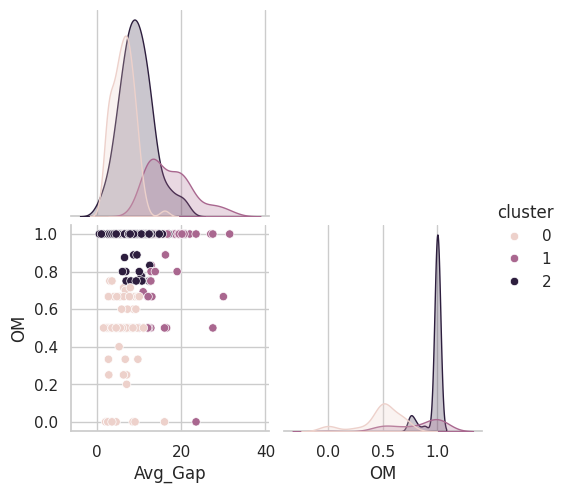

In [ ]:
sns.pairplot(dir_features, vars=['Avg_Gap','OM'], hue='cluster', corner=True)

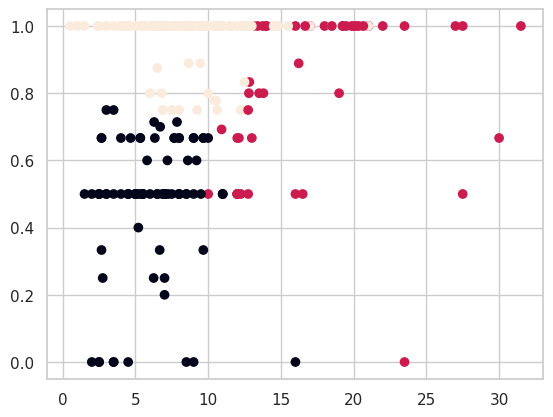

In [ ]:
plt.scatter(dir_features['Avg_Gap'],dir_features['OM'], c=dir_features['cluster'])

**Interpretation **

In the table we can see the Average Age Gap and the Standard Deviation of the Age Gap for each cluster. We can also see in this table and the following pairplot that when the directors have directed 3 more movies that there are very little, if any, gender pairings that had an Older Female, Male Male, or Female-Female relationships. Inferring that a succesful director has director has directored 3 or more movies, this means that the directors chose to have a male/female relationship in which the Male was older. It is hard to distinguish exactly which directors had a prefrence for age gap, but what can see is that cluster 0 had the smallest age gap, followed by cluster 2, then cluster 3.

## 12) Next Steps

This document doesn't yet account for the pairings being flipped, in which the older character is character 2 opposed to character to 1. It also doesn't account for exactly how each director compares to others. I look forward to continuing to improving the variables and understanding the data.


